In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')




In [3]:
census = pd.read_csv('D:/Users/Admin/CODE FILES/AI-ML CODE/ML CODE/Adult-Census-Income-Navie-Baiyes-p6/census-data/adult.csv')

In [4]:
census

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [5]:
census.head(20)

# jst by having an egalatrian view on this data and i found some thing uniquw in the data and it is that there '?' instead of the null or nan, and if we check in the info as we dont see any nulls b ecause the of '?' so we need to convert all the '?' with the np.nans


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [6]:
census.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [7]:
census['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [8]:
census.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

In [9]:
census.describe()
# in describe the age looks quite normal the doubt is the other features over here where in capital gain and loss mean is 1k amd 87 but the 25%,50%,75% are 0 why ?? and the max his also 99999 4358 simultaneously hours per week also seems quite normal yeah but i can see 1 hour but i think its valid according to the criteria but one thing 25% ppl work 40 hrs and 50% also do 40hrs what the point here ?? and 75 % ppl do 45 so i am not getting this 

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
census['capital.loss'].value_counts()

capital.loss
0       31042
1902      202
1977      168
1887      159
1848       51
        ...  
1944        1
1844        1
1539        1
1411        1
155         1
Name: count, Length: 92, dtype: int64

In [11]:
census.describe(include="all")

# prompt for the ai  -- > we have done this include all as well but its something diffrent unable to understand need u too help me out witht this 


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [12]:
# So what happened in this dataset?

# In 1994, the US Census Bureau collected information from millions of people.

# Researchers Ronny Kohavi and Barry Becker took a cleaned portion of that data and created this dataset.

# Their question became:

# Can we predict whether someone earns more than $50,000 per year?

# Notice something.

# The government already knows everyone's income.

# The goal isn't to guess unknown income.

# The goal is to see whether patterns in people's lives can predict their income.

In [13]:
# so in this we are judgjing the patern not the only outcome 

In [14]:
census.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [15]:
census['fnlwgt']

0         77053
1        132870
2        186061
3        140359
4        264663
          ...  
32556    310152
32557    257302
32558    154374
32559    151910
32560    201490
Name: fnlwgt, Length: 32561, dtype: int64

In [16]:
census.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

In [17]:
# understand this whole data and the discription of the data .

# this data contained the millions of ppl data in the year od 1994 but this data is filter and cleaned and remaing 48k coloums are left 
#  so this are the criteria age shoudl be bigger then 16, AGI ( Adjusted Gross Income ) should he greater then 100 cause ppl earning less then this can cause noise in data , HRSWK should be greater then 0 work hour should be greater ,fnlwgt ( final weigth ) final weight should be more then 1 now what does it mean it simply means that the 1 representers to the other for eg there are milions of ppl in the city or starte now its imporssible to go and reach them all so we interview 50k out of 500k so the 1 per son represent 1k so 1k is the final weight . and we were raking ( simply means that we were adding on the data  ) the dara untill it match the real population

In [18]:
# # new knowledge -->

# #╔══════════════════════════════════════════════════════════════════════════════╗
# ║                      EDA GRAPH SELECTION CHEAT SHEET                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 1. How many categories are there?                                           │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Countplot                                                      │
# │ Purpose    : Shows the distribution of categorical values                   │
# │ Example    : Gender, Occupation, Marital Status                             │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 2. What is the distribution of a numerical feature?                         │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Histogram                                                      │
# │ Purpose    : Shows the shape and spread of numerical data                   │
# │ Example    : Age, Salary, Income, Price                                     │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 3. Is the data skewed?                                                      │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : KDE Plot                                                       │
# │ Purpose    : Smooth distribution curve showing skewness                     │
# │ Example    : Capital Gain, Income                                           │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 4. Are there outliers?                                                      │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Boxplot                                                        │
# │ Purpose    : Detects extreme values and shows quartiles                     │
# │ Example    : Age, Income, House Price                                       │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 5. How does the target change across categories?                            │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Countplot (hue = Target)                                       │
# │ Purpose    : Compare target distribution for each category                  │
# │ Example    : Occupation vs Income                                            │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 6. How do two numerical features relate?                                    │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Scatter Plot                                                   │
# │ Purpose    : Detect correlation, trends and relationships                   │
# │ Example    : Age vs Hours per Week                                          │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 7. How does one numerical feature vary across categories?                   │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Violin Plot                                                    │
# │ Purpose    : Shows distribution + density + median                          │
# │ Example    : Age grouped by Income                                          │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 8. Same analysis but simpler                                                │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Boxplot                                                        │
# │ Purpose    : Compare medians, spread and outliers                           │
# │ Example    : Salary grouped by Department                                   │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 9. Is there a linear relationship among multiple features?                  │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Pairplot                                                       │
# │ Purpose    : Compare every numerical feature with every other feature        │
# │ Example    : Age, Hours, Capital Gain, Education Number                     │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 10. Which numerical features are correlated?                                │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Correlation Heatmap                                            │
# │ Purpose    : Displays correlation coefficients                              │
# │ Example    : Age, Education Number, Hours, Capital Gain                     │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 11. How are two categorical features associated?                            │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Crosstab + Heatmap                                             │
# │ Purpose    : Compare category combinations                                  │
# │ Example    : Education vs Income                                            │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 12. Which values occur most often?                                          │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Bar Chart                                                      │
# │ Purpose    : Compare frequencies or aggregated values                       │
# │ Example    : Top Occupations                                                │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 13. How does a feature change over time?                                    │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Line Plot                                                      │
# │ Purpose    : Visualize trends over time                                     │
# │ Example    : Monthly Sales                                                  │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 14. What proportion does each category contribute?                          │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Pie Chart (Use Sparingly)                                      │
# │ Purpose    : Show part-to-whole relationships                               │
# │ Example    : Income Classes                                                 │
# └──────────────────────────────────────────────────────────────────────────────┘


# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ 15. Are there hidden clusters or class separation?                          │
# ├──────────────────────────────────────────────────────────────────────────────┤
# │ Best Graph : Pairplot / Scatter Plot                                        │
# │ Purpose    : Identify natural groupings or separable classes                │
# │ Example    : Income Classes by Age & Hours                                  │
# └──────────────────────────────────────────────────────────────────────────────┘

In [19]:
# okay so before plotting any graphs we need to see how many numericall features we have in  the data.


numerical_col = census.select_dtypes(include='number').columns
categorical_col = census.select_dtypes(include='object').columns

print(numerical_col)
print(categorical_col)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')
Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')


In [20]:
# working on each of the col and understanding them 

print('\n', census['age'].describe())
print('\n',census['age'].median())
print('\n',census['age'].mode())

# greater then zero right skewed less then zero left skewed 
print('\n',census['age'].skew())


print('\n',census['age'].kurt())




 count    32561.000000
mean        38.581647
std         13.640433
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

 37.0

 0    36
Name: age, dtype: int64

 0.5587433694130484

 -0.16612745957143904


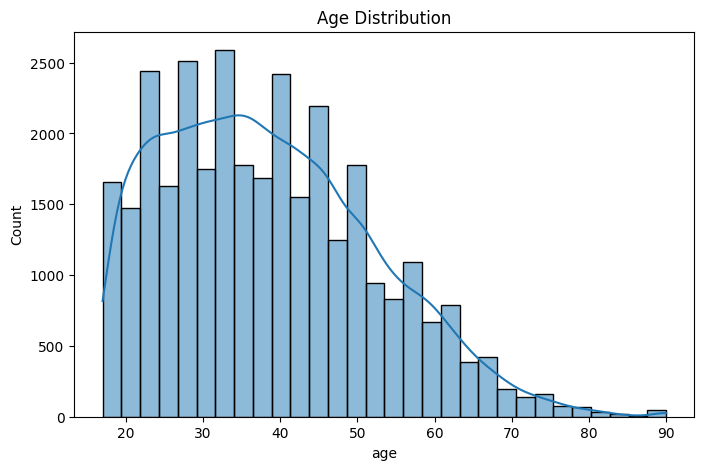

In [21]:
# visualizing the data

plt.figure(figsize=(8,5))
sns.histplot(census['age'],bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

In [22]:
# Is the data normal?
# --> yes the data seems to be normal to mee 

# Is it skewed?
# the data is right skewed

# Are there multiple peaks?
# it have many peaks

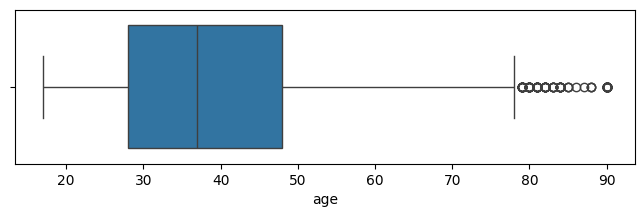

In [23]:
plt.figure(figsize=(8,2))

sns.boxplot(x=census['age'])

plt.show()

In [24]:
# yes there are outliers which is 80+ 90 


<Axes: xlabel='income', ylabel='age'>

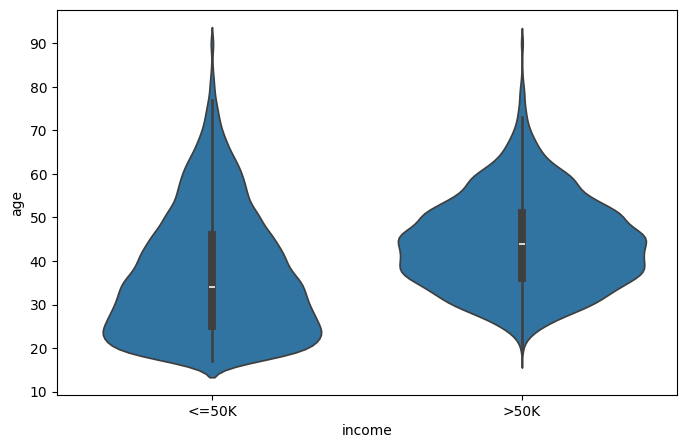

In [25]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='income',
    y='age',
    data=census
)

In [26]:
# so this is something new now that the young ppl who are in there early 20s are getting paid or earning more then 50k and the ppl in the 45 to 50 there earning less then 50k, no am sorry its the opposite 

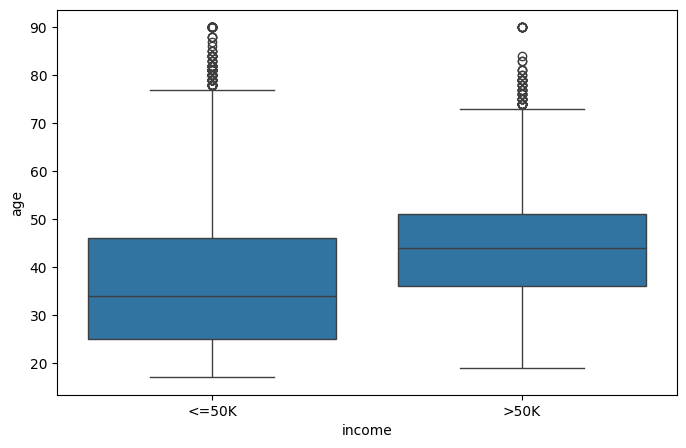

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='income',
    y='age',
    data=census
)

plt.show()

In [28]:
# yes we can see here in the box plot aswell its the same here also we have the outlier

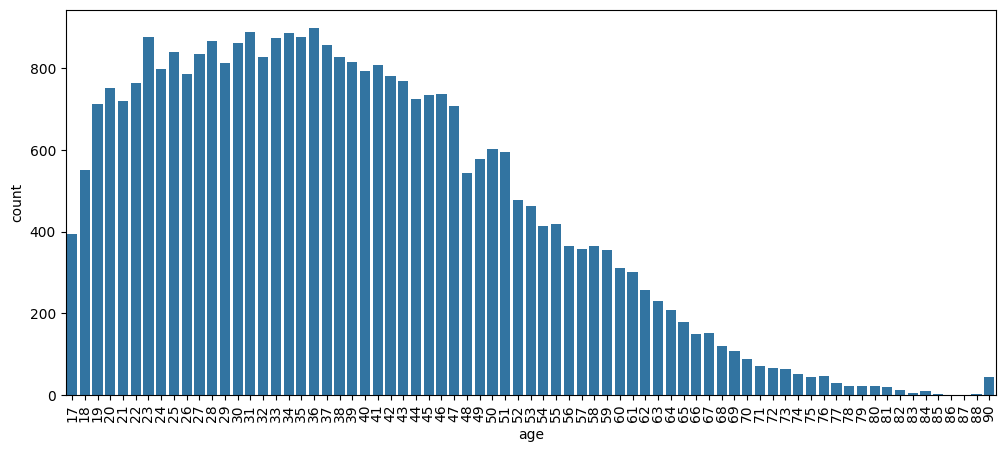

In [29]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='age',
    data=census
)

plt.xticks(rotation=90)

plt.show()

In [30]:
# again there is and right skewed graph and here also we can see the max ppl are from there 24s 32s and 40s 

# small conclusion is that the age is highly skewed  and if we check the voilin , so there is a diffrenece of around 10 years but still its  overlaping so this cannnnot be the ground breaking feature to diffrentiate 

In [31]:
census['education'].head()

# does this education affects the income , if we logically think then the answer is yes , but we cant judge with out doing the research , there can be some local business mans who are not so well educated but are earning more so yess need to see the visuaul report 

0         HS-grad
1         HS-grad
2    Some-college
3         7th-8th
4    Some-college
Name: education, dtype: str

In [32]:

print('\n',census['education'].describe()
)
print('\n',census['education'].value_counts()
)
print('\n',census['education'].value_counts(normalize=True) * 100
)


 count       32561
unique         16
top       HS-grad
freq        10501
Name: education, dtype: object

 education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

 education
HS-grad         32.250238
Some-college    22.391818
Bachelors       16.446055
Masters          5.291607
Assoc-voc        4.244341
11th             3.608612
Assoc-acdm       3.276926
10th             2.865391
7th-8th          1.983969
Prof-school      1.768987
9th              1.578576
12th             1.329812
Doctorate        1.268389
5th-6th          1.022696
1st-4th          0.515955
Preschool        0.156629
Name: proportion, dtype: float64


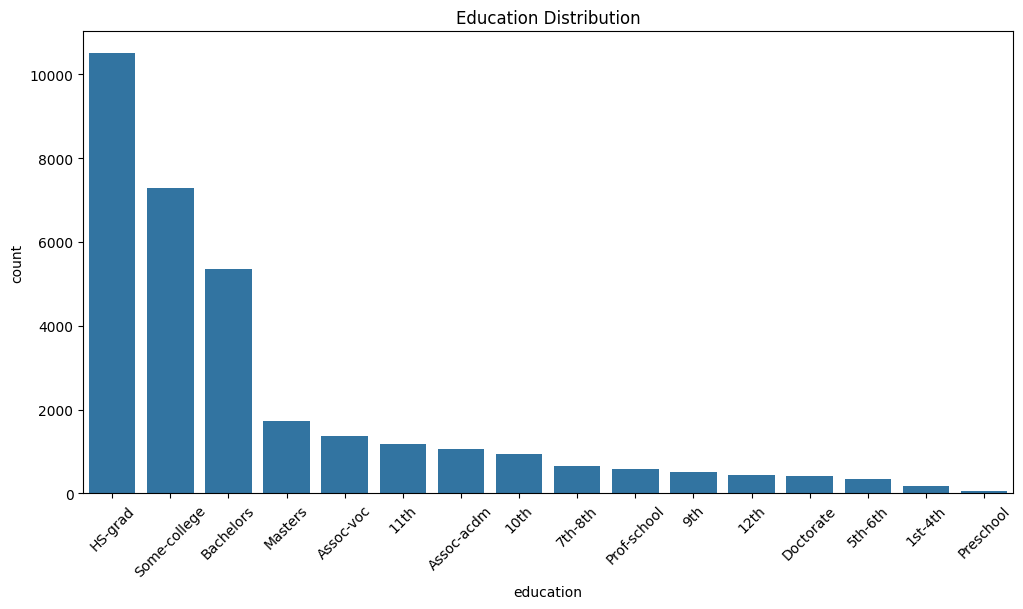

In [33]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='education',
    
    data=census,
    order=census['education'].value_counts().index
)

plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.show()

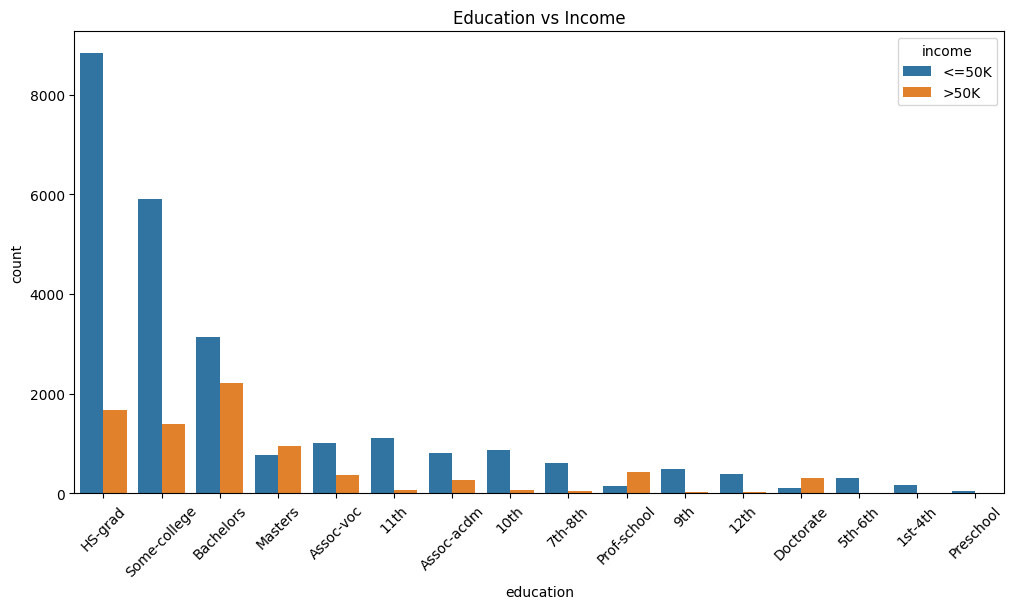

In [34]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='education',
    hue='income',
    data=census,
    order=census['education'].value_counts().index
)

plt.title("Education vs Income")
plt.xticks(rotation=45)

plt.show()

In [35]:
# i am little confused and unbale to judge this graph at some extent i am unable to understand the trend in it all i can see is the educated are surely earning more so we can get the oucome that the more educated u are more likeyly u are going to earn so i think for that reason u need to keep this feature 

In [36]:
pd.crosstab(
    census['education'],
    census['income'],
    normalize='index'
) * 100

# yes as we can see from the cross tab there is so much of an diffrentiation in the graph here the more educated the ppl are the higher level certificate they are holding the better chance are there of making more money 

income,<=50K,>50K
education,,
10th,93.354770,6.645230
11th,94.893617,5.106383
12th,92.378753,7.621247
1st-4th,96.428571,3.571429
5th-6th,95.195195,4.804805
7th-8th,93.808050,6.191950
9th,94.747082,5.252918
Assoc-acdm,75.164011,24.835989
Assoc-voc,73.878437,26.121563


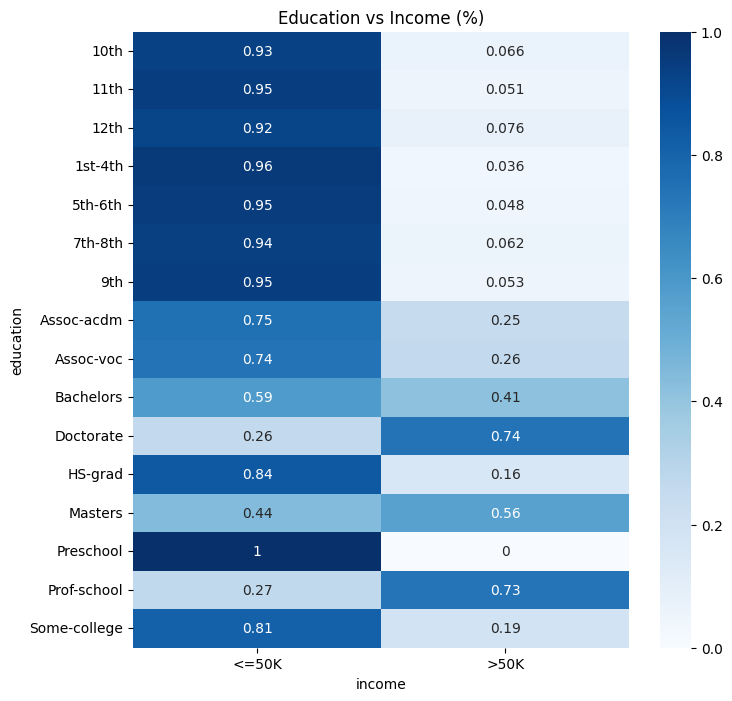

In [37]:
plt.figure(figsize=(8,8))

sns.heatmap(
    pd.crosstab(
        census['education'],
        census['income'],
        normalize='index'
    ),
    annot=True,
    cmap='Blues'
)

plt.title("Education vs Income (%)")

plt.show()

# i am unable to understand the heatmap graph 

In [38]:
# practising asking the business related questions by group by -->


census.groupby('education')['age'].mean().sort_values(ascending=False)

education
7th-8th         48.445820
Doctorate       47.702179
1st-4th         46.142857
Prof-school     44.746528
Masters         44.049913
5th-6th         42.885886
Preschool       42.764706
9th             41.060311
HS-grad         38.974479
Bachelors       38.904949
Assoc-voc       38.553546
10th            37.429796
Assoc-acdm      37.381443
Some-college    35.756275
11th            32.355745
12th            32.000000
Name: age, dtype: float64

In [39]:
census.groupby('education')["hours.per.week"].mean().sort_values(ascending=False)

education
Prof-school     47.425347
Doctorate       46.973366
Masters         43.836332
Bachelors       42.614006
Assoc-voc       41.610709
HS-grad         40.575374
Assoc-acdm      40.504217
7th-8th         39.366873
5th-6th         38.897898
Some-college    38.852284
1st-4th         38.255952
9th             38.044747
10th            37.052519
Preschool       36.647059
12th            35.780600
11th            33.925957
Name: hours.per.week, dtype: float64

In [40]:
census.groupby("education")["capital.gain"].mean().sort_values(ascending=False)

education
Prof-school     10414.416667
Doctorate        4770.145278
Masters          2562.563552
Bachelors        1756.299533
Preschool         898.392157
Assoc-voc         715.051375
Assoc-acdm        640.399250
Some-college      598.824167
HS-grad           576.800114
10th              404.574491
9th               342.089494
12th              284.087760
7th-8th           233.939628
11th              215.097872
5th-6th           176.021021
1st-4th           125.875000
Name: capital.gain, dtype: float64

In [41]:
census.groupby("income")[["age","hours.per.week","capital.gain"]].mean()

,age,hours.per.week,capital.gain
income,,,
<=50K,36.783738,38.840210,148.752468
>50K,44.249841,45.473026,4006.142456


In [42]:

census.groupby('education')['age'].agg(
    ["mean","median","min","max","std"]
)

,mean,median,min,max,std
education,,,,,
10th,37.429796,34.0,17,90,16.720713
11th,32.355745,28.0,17,90,15.545485
12th,32.000000,28.0,17,79,14.334625
1st-4th,46.142857,46.0,19,90,15.615625
5th-6th,42.885886,42.0,17,84,15.557285
7th-8th,48.445820,50.0,17,90,16.092350
9th,41.060311,39.0,17,90,15.946862
Assoc-acdm,37.381443,36.0,19,90,11.095177
Assoc-voc,38.553546,37.0,19,84,11.631300


In [43]:
(
    census.groupby("education")["age"]
      .mean()
      .sort_values(ascending=False)
)

education
7th-8th         48.445820
Doctorate       47.702179
1st-4th         46.142857
Prof-school     44.746528
Masters         44.049913
5th-6th         42.885886
Preschool       42.764706
9th             41.060311
HS-grad         38.974479
Bachelors       38.904949
Assoc-voc       38.553546
10th            37.429796
Assoc-acdm      37.381443
Some-college    35.756275
11th            32.355745
12th            32.000000
Name: age, dtype: float64

In [44]:
census.groupby('sex')['capital.gain'].mean()

sex
Female     568.410547
Male      1329.370078
Name: capital.gain, dtype: float64

In [45]:
# census.groupby('occupation')['income'].mean() need to check

In [46]:
census.groupby('occupation')['age'].mean()


occupation
?                    40.882800
Adm-clerical         36.964456
Armed-Forces         30.222222
Craft-repair         39.031471
Exec-managerial      42.169208
Farming-fishing      41.211268
Handlers-cleaners    32.165693
Machine-op-inspct    37.715285
Other-service        34.949621
Priv-house-serv      41.724832
Prof-specialty       40.517633
Protective-serv      38.953775
Sales                37.353973
Tech-support         37.022629
Transport-moving     40.197871
Name: age, dtype: float64

In [47]:
census.groupby('workclass')['hours.per.week'].mean()

workclass
?                   31.919390
Federal-gov         41.379167
Local-gov           40.982800
Never-worked        28.428571
Private             40.267096
Self-emp-inc        48.818100
Self-emp-not-inc    44.421881
State-gov           39.031587
Without-pay         32.714286
Name: hours.per.week, dtype: float64

In [48]:
census.groupby('marital.status')['capital.gain'].mean()

marital.status
Divorced                  728.414810
Married-AF-spouse         432.652174
Married-civ-spouse       1764.859509
Married-spouse-absent     653.983254
Never-married             376.588318
Separated                 535.568780
Widowed                   571.071501
Name: capital.gain, dtype: float64

In [49]:
census[['marital.status','capital.gain']]
census[['occupation','income']]
census['income']

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557    <=50K
32558     >50K
32559    <=50K
32560    <=50K
Name: income, Length: 32561, dtype: str

In [50]:
census[census['income'] == '>50K'].groupby('education')['hours.per.week'].mean()

education
10th            43.774194
11th            45.133333
12th            44.818182
1st-4th         48.833333
5th-6th         46.000000
7th-8th         47.500000
9th             44.851852
Assoc-acdm      44.256604
Assoc-voc       43.853186
Bachelors       45.475462
Doctorate       47.513072
HS-grad         45.042985
Masters         45.917623
Prof-school     49.092199
Some-college    44.820476
Name: hours.per.week, dtype: float64

In [51]:
(
    census
    .groupby('education')['age']
    .mean()
    .sort_values(ascending=False)
    .loc[lambda x: x > 40]
)

# will stufyu after words


education
7th-8th        48.445820
Doctorate      47.702179
1st-4th        46.142857
Prof-school    44.746528
Masters        44.049913
5th-6th        42.885886
Preschool      42.764706
9th            41.060311
Name: age, dtype: float64

In [52]:
# hours per week

print('\n',census['hours.per.week'].describe())
print('\n',census['hours.per.week'].skew())
print('\n',census['hours.per.week'].kurt())


 count    32561.000000
mean        40.437456
std         12.347429
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours.per.week, dtype: float64

 0.227642536804501

 2.9166867960020677


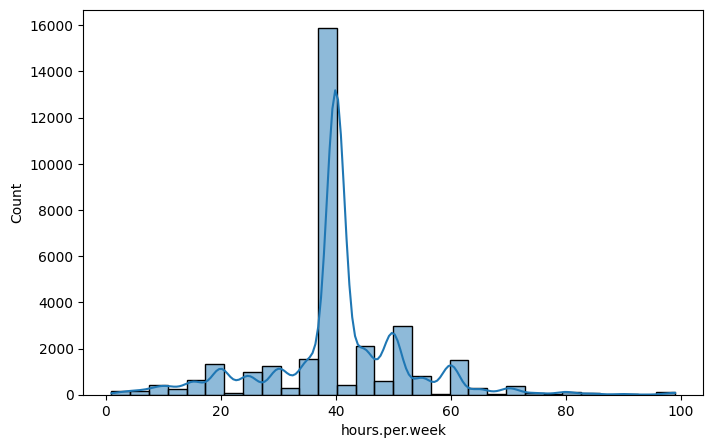

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    census['hours.per.week'],
    kde=True,
    bins=30
)

plt.show()

# is the feature skewed ?
# no the feature is not skewed feature has a good peak which in at 38 to 40 hours 

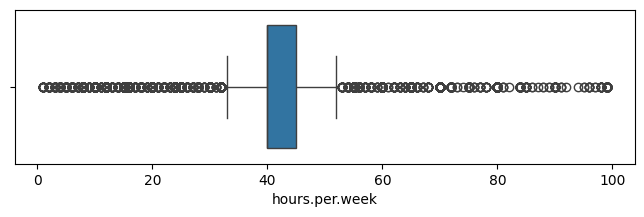

In [54]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=census['hours.per.week']
)

plt.show()

# is there a outlier ->
# yes there are many out liers both the side 

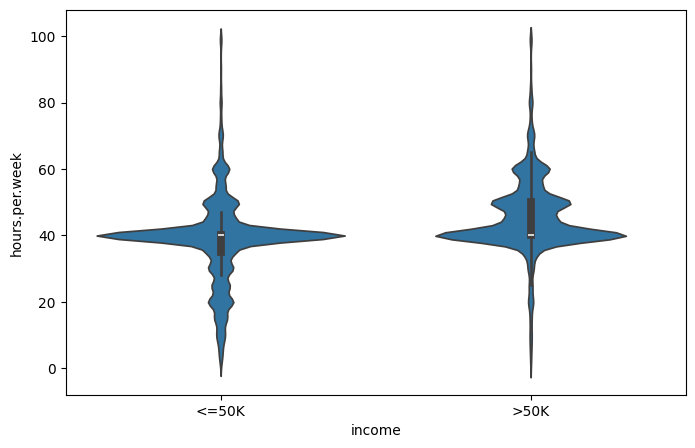

In [55]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='income',
    y='hours.per.week',
    data=census
)

plt.show()

# yes the 40 hr is the most common value in both the criteria weather it less or more then 50k they median is also 40
# the people work ing more our are the one definelity gettting paid but on the other side there are also ppl who are working more then 40 hr but still earning under 50k there is not much of a diffrence 

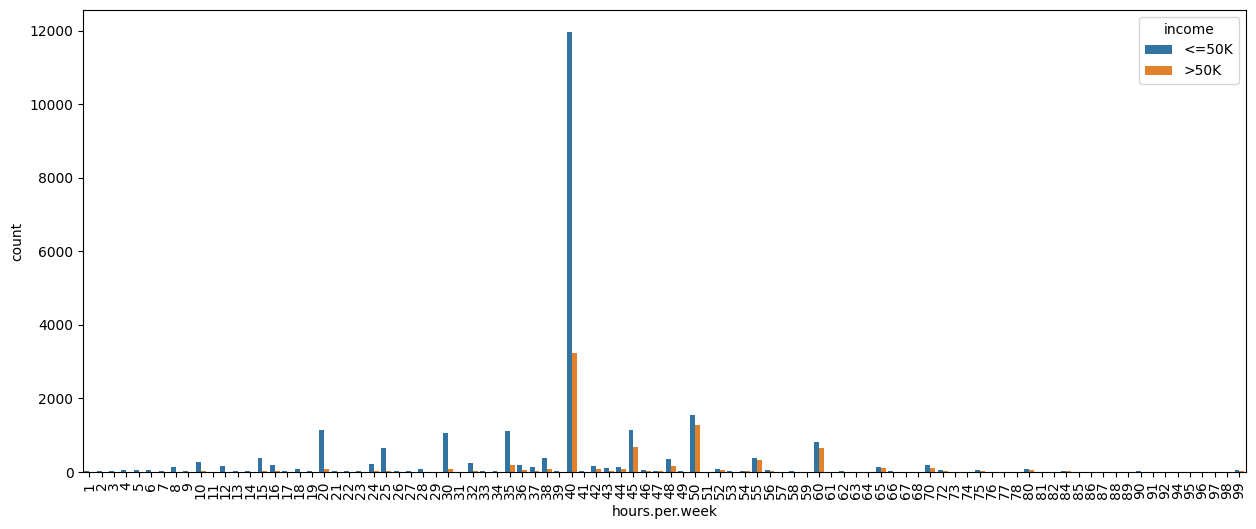

In [56]:
plt.figure(figsize=(15,6))

sns.countplot(
    x='hours.per.week',
    hue='income',
    data=census
)

plt.xticks(rotation=90)

plt.show()

# this is feature is comparatievly weaker then the education because there is no such visible visual diffrence and even on the data level

In [57]:
pd.crosstab(
    census['hours.per.week'],
    census['income'],
    normalize='index'
) * 100

income,<=50K,>50K
hours.per.week,,
1,90.000000,10.000000
2,75.000000,25.000000
3,97.435897,2.564103
4,94.444444,5.555556
5,88.333333,11.666667
...,...,...
95,50.000000,50.000000
96,80.000000,20.000000
97,50.000000,50.000000


In [58]:
# cleaning the '?' cause we forgot to do it 

census.replace('?', np.nan, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [59]:
census.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [60]:
(census.isnull().sum() / len(census)) * 100

age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education.num     0.000000
marital.status    0.000000
occupation        5.660146
relationship      0.000000
race              0.000000
sex               0.000000
capital.gain      0.000000
capital.loss      0.000000
hours.per.week    0.000000
native.country    1.790486
income            0.000000
dtype: float64

In [61]:
census.duplicated().sum()

np.int64(24)

In [62]:
print(census['workclass'])
print(census['occupation'])

census['workclass'].value_counts()

0            NaN
1        Private
2            NaN
3        Private
4        Private
          ...   
32556    Private
32557    Private
32558    Private
32559    Private
32560    Private
Name: workclass, Length: 32561, dtype: str
0                      NaN
1          Exec-managerial
2                      NaN
3        Machine-op-inspct
4           Prof-specialty
               ...        
32556      Protective-serv
32557         Tech-support
32558    Machine-op-inspct
32559         Adm-clerical
32560         Adm-clerical
Name: occupation, Length: 32561, dtype: str


workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [63]:
# Can I build a model using education, age, workclass, and other available features to predict the missing occupation?"
# This is called domain-informed imputation.


In [64]:
census['workclass'].unique()

census['workclass'] = census['workclass'].fillna('Unknown', inplace=True)
census['occupation'] = census['occupation'].fillna('Unknown', inplace=True)
census['native.country'] = census['native.country'].fillna('Unknown', inplace=True)



In [65]:
census.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [66]:
# feature - capital gain

print('\n',census['capital.gain'].describe())

print('\n',census['capital.gain'].skew())

print('\n',census['capital.gain'].kurt())


 count    32561.000000
mean      1077.648844
std       7385.292085
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital.gain, dtype: float64

 11.953847687699787

 154.79943785425328


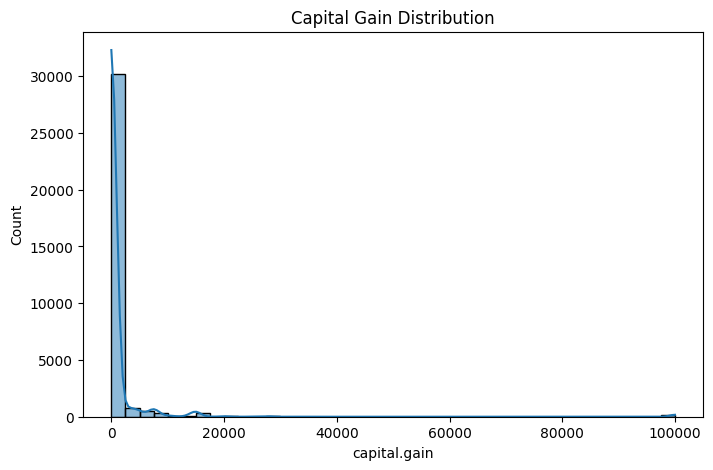

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(
    census['capital.gain'],
    bins=40,
    kde=True
)

plt.title("Capital Gain Distribution")
plt.show()

# maximumm ppl have 0 to 1000 capital gain 

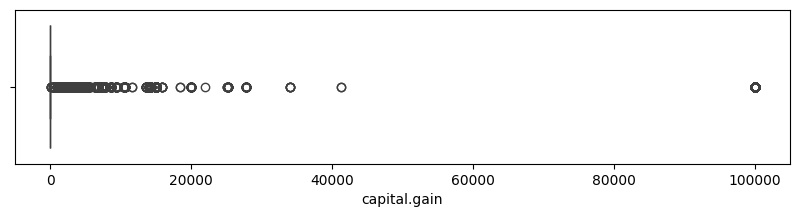

In [68]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=census['capital.gain']
)

plt.show()

# as maximum ppl are at 0 then the outliers are every where

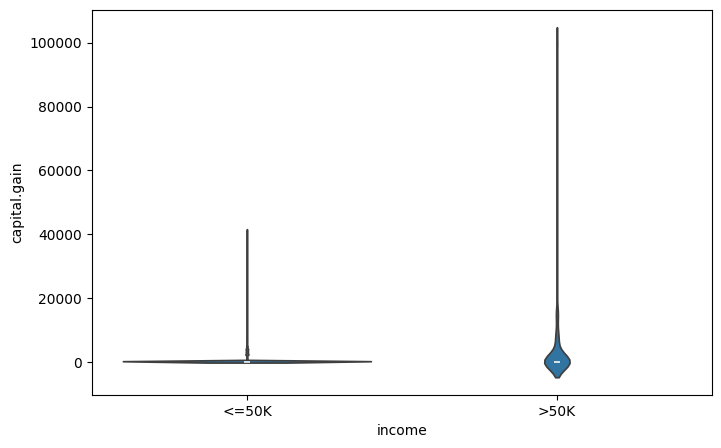

In [69]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='income',
    y='capital.gain',
    data=census
)

plt.show()

# in voilen as well we can see that the both of the graph make no such dfferenc there is a slight one and the logical one that the ppl who are making the capitalgain are the one who are makiing above 50k 
# small conclusion is that this capital gain makes no such diffrenece well keep this for sure itll will help but we should also check once dropiing it

In [70]:
pd.crosstab(
    census['capital.gain'] > 0,
    census['income'],
    normalize='index'
) * 100

income,<=50K,>50K
capital.gain,,
False,79.349392,20.650608
True,38.163717,61.836283


In [71]:
print('\n',census['capital.loss'].describe())

print('\n',census['capital.loss'].skew())

print('\n',census['capital.loss'].kurt())


 count    32561.000000
mean        87.303830
std        402.960219
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital.loss, dtype: float64

 4.594629121679698

 20.37680171341222


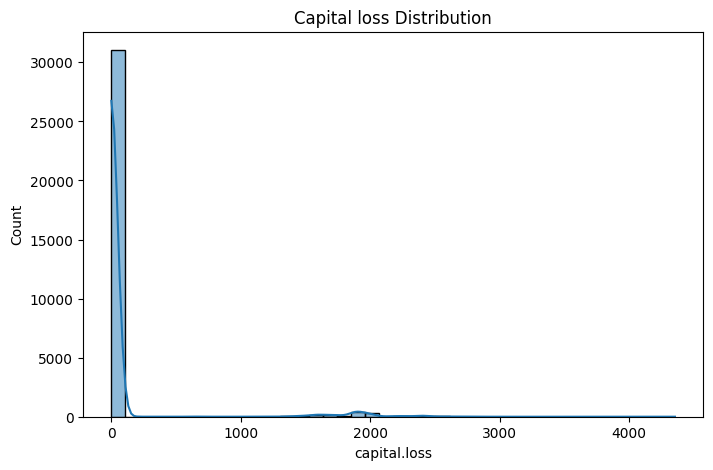

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(
    census['capital.loss'],
    bins=40,
    kde=True
)

plt.title("Capital loss Distribution")
plt.show()


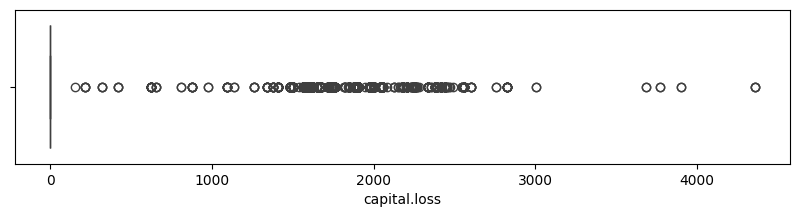

In [73]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=census['capital.loss']
)

plt.show()

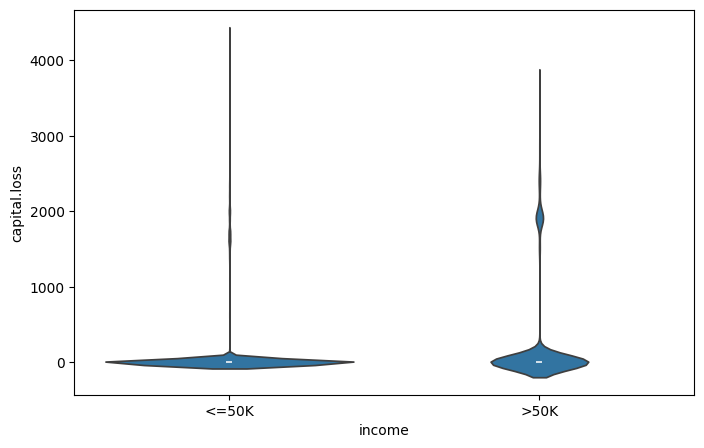

In [74]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='income',
    y='capital.loss',
    data=census
)

plt.show()

In [75]:
pd.crosstab(
    census['capital.loss'] > 0,
    census['income'],
    normalize='index'
) * 100

income,<=50K,>50K
capital.loss,,
False,77.230849,22.769151
True,49.111257,50.888743


In [ ]:
# feature - occupation
# now we are starting on with the categorical features 


In [76]:
census['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Unknown              1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [77]:
census['occupation'].value_counts(normalize=True) * 100

occupation
Prof-specialty       12.714597
Craft-repair         12.588680
Exec-managerial      12.487331
Adm-clerical         11.578268
Sales                11.209729
Other-service        10.119468
Machine-op-inspct     6.148460
Unknown               5.660146
Transport-moving      4.904641
Handlers-cleaners     4.207487
Farming-fishing       3.052732
Tech-support          2.850035
Protective-serv       1.993182
Priv-house-serv       0.457603
Armed-Forces          0.027640
Name: proportion, dtype: float64

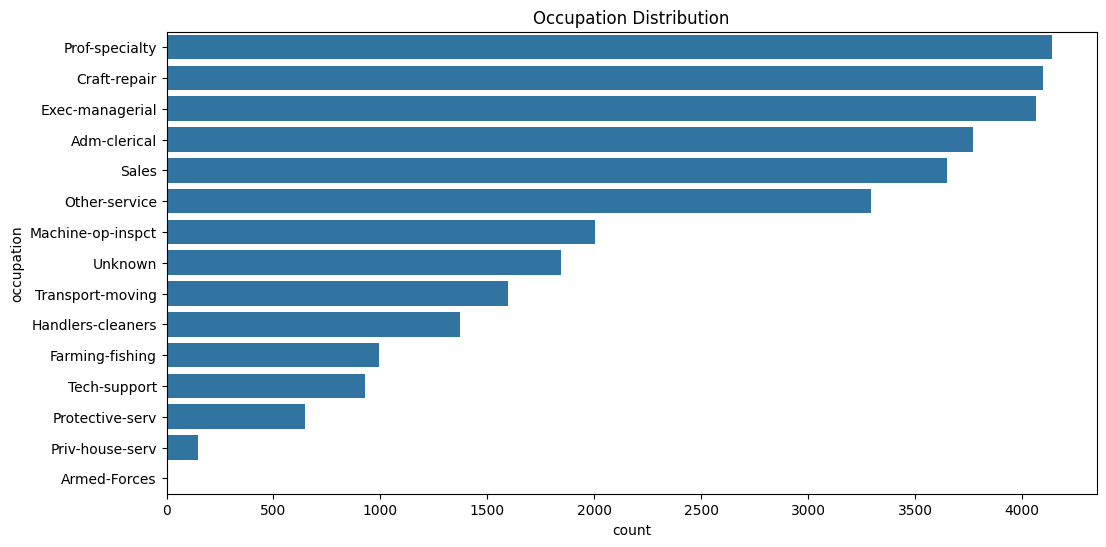

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='occupation',
    data=census,
    order=census['occupation'].value_counts().index
)

plt.title("Occupation Distribution")

plt.show()

# so in this the graph is progressively right skewed , and over here the most common work force are in prof-speciality , craft repair, exec managerial

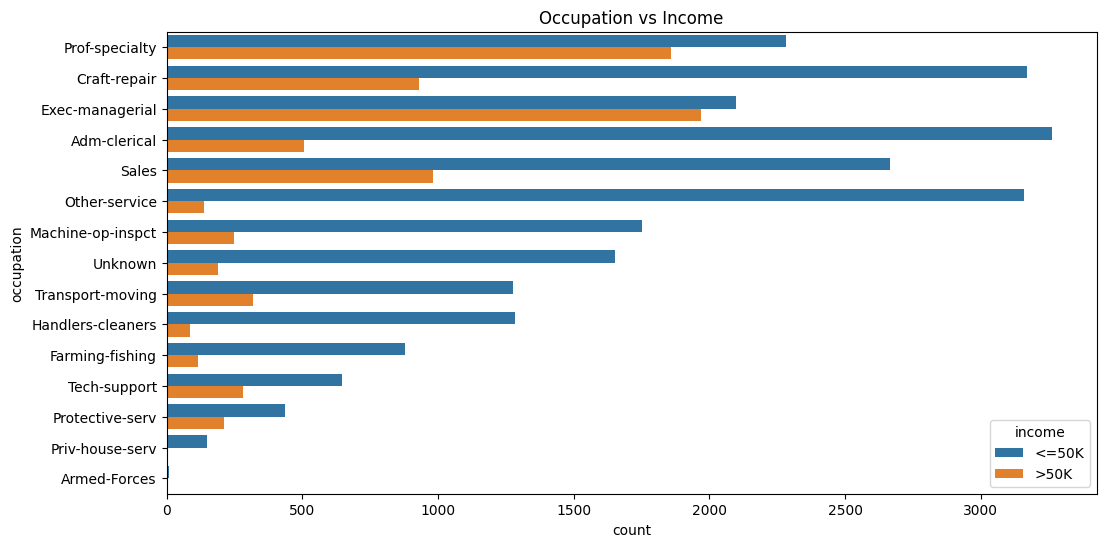

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='occupation',
    hue='income',
    data=census,
    order=census['occupation'].value_counts().index
)

plt.title("Occupation vs Income")

plt.show()

# okay so this is my observation in this that we wont judge the graphs by the height of it well judge them by the diffrence btw the earners and the non earners 
# for eg: prof-speciality has 2600 under 50k and 2000 over 50k comparing  ot the craft -rep 3k+ are earning under and around 1k are earning higher 
# so in this we should judge them on the basis of the diffrence percentage btw the both 

# prof , craft, exec-man, sales , this are the one which are likely to earn morethen 50k nbut there are some occupation which are priv-house , farming. transport , handler-clener are the one who are unable to earn this much
# 
# unknonw one have more under paid  and some 200 to  250 who are earning more 
# yes we should keep it althought i stronfgly recommend to check with out this ,,,,, for sure occupation helps judge and it quite importatnt to judge the sakary 

In [ ]:
pd.crosstab(
    census['occupation'],
    census['income'],
    normalize='index'
) * 100

# again this feature is making me little confuse how to judge them and on what bassis as specially this occupation vs income grpah
# as we can see in every case and in every occupationthe under 50k is always higher then the above one 

income,<=50K,>50K
occupation,,
Adm-clerical,86.551724,13.448276
Armed-Forces,88.888889,11.111111
Craft-repair,77.335936,22.664064
Exec-managerial,51.598623,48.401377
Farming-fishing,88.430584,11.569416
Handlers-cleaners,93.722628,6.277372
Machine-op-inspct,87.512488,12.487512
Other-service,95.842185,4.157815
Priv-house-serv,99.328859,0.671141


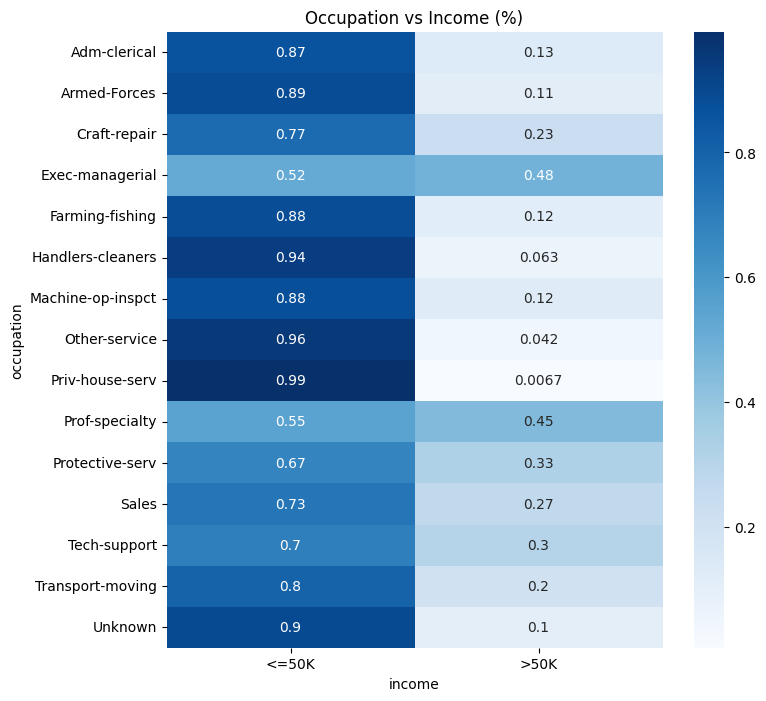

In [88]:
plt.figure(figsize=(8,8))

sns.heatmap(
    pd.crosstab(
        census['occupation'],
        census['income'],
        normalize='index'
    ),
    annot=True,
    cmap='Blues'
)

plt.title("Occupation vs Income (%)")

plt.show()

marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
marital.status
Married-civ-spouse       45.993673
Never-married            32.809189
Divorced                 13.645158
Separated                 3.147938
Widowed                   3.049661
Married-spouse-absent     1.283744
Married-AF-spouse         0.070637
Name: proportion, dtype: float64


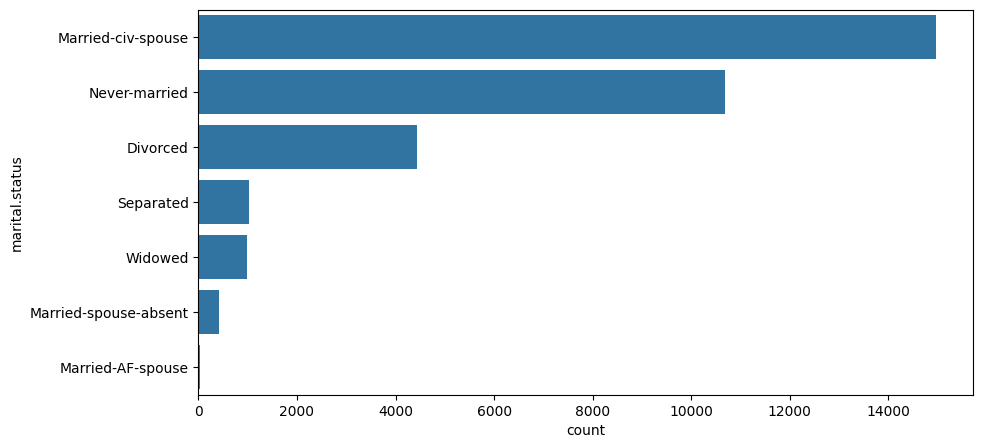

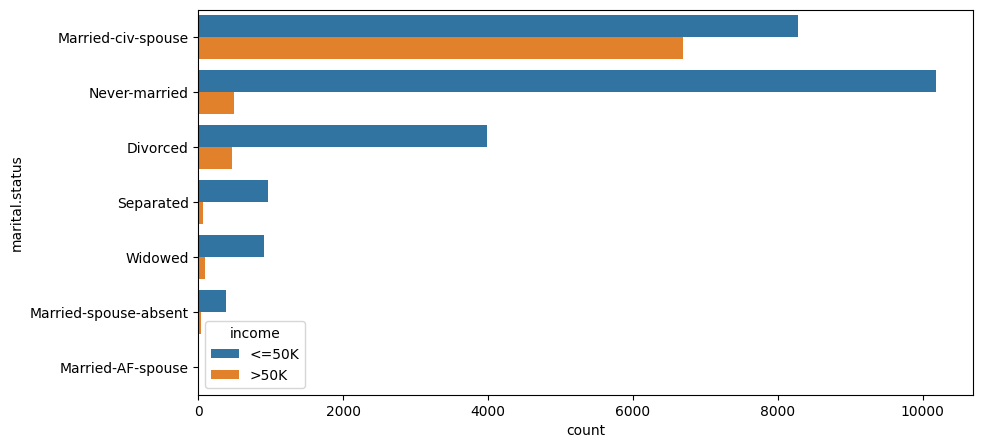

income,<=50K,>50K
marital.status,,
Divorced,89.579113,10.420887
Married-AF-spouse,56.521739,43.478261
Married-civ-spouse,55.315171,44.684829
Married-spouse-absent,91.866029,8.133971
Never-married,95.403913,4.596087
Separated,93.560976,6.439024
Widowed,91.440081,8.559919


In [90]:
# maratial status -->
print(census['marital.status'].value_counts())

# Percentage
print(census['marital.status'].value_counts(normalize=True) * 100)

# Countplot
plt.figure(figsize=(10,5))

sns.countplot(
    y='marital.status',
    data=census,
    order=census['marital.status'].value_counts().index
)

plt.show()

# Income comparison
plt.figure(figsize=(10,5))

sns.countplot(
    y='marital.status',
    hue='income',
    data=census,
    order=census['marital.status'].value_counts().index
)

plt.show()

# Crosstab
pd.crosstab(
    census['marital.status'],
    census['income'],
    normalize='index'
) * 100

In [ ]:
# most common in here is the married person and his also the on who is making the more money 
# and the graph is also progressievly right skwed loweset one is some one around the 10 - 15 
# hight ppl earning >50k is the maried civ 
# yes we should keep it 

relationship
Husband           13193
Not-in-family      8305
Own-child          5068
Unmarried          3446
Wife               1568
Other-relative      981
Name: count, dtype: int64


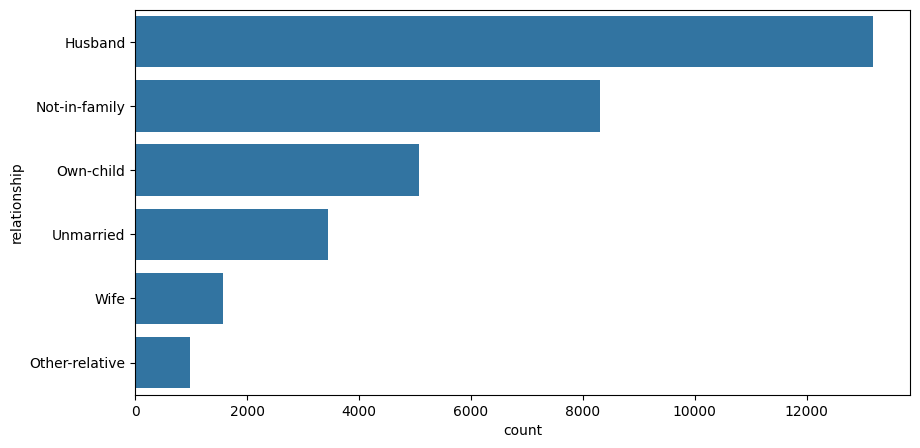

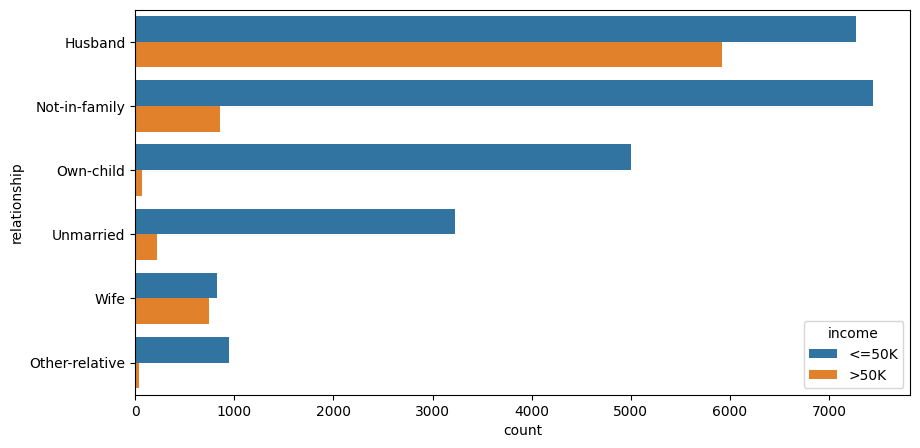

income,<=50K,>50K
relationship,,
Husband,55.142879,44.857121
Not-in-family,89.692956,10.307044
Other-relative,96.228338,3.771662
Own-child,98.677979,1.322021
Unmarried,93.673825,6.326175
Wife,52.487245,47.512755


In [ ]:
print(census['relationship'].value_counts())

plt.figure(figsize=(10,5))

sns.countplot(
    y='relationship',
    data=census,
    order=census['relationship'].value_counts().index
)

plt.show()

plt.figure(figsize=(10,5))

sns.countplot(
    y='relationship',
    hue='income',
    data=census,
    order=census['relationship'].value_counts().index
)

plt.show()

pd.crosstab(
    census['relationship'],
    census['income'],
    normalize='index'
) * 100

# one thig i found our little shockng tha tht eh women who are earning more then 50k is higher then husband, if it s44 for man hen its 57 by the wide s
# 


0         9
1         9
2        10
3         4
4        10
         ..
32556    10
32557    12
32558     9
32559     9
32560     9
Name: education.num, Length: 32561, dtype: int64

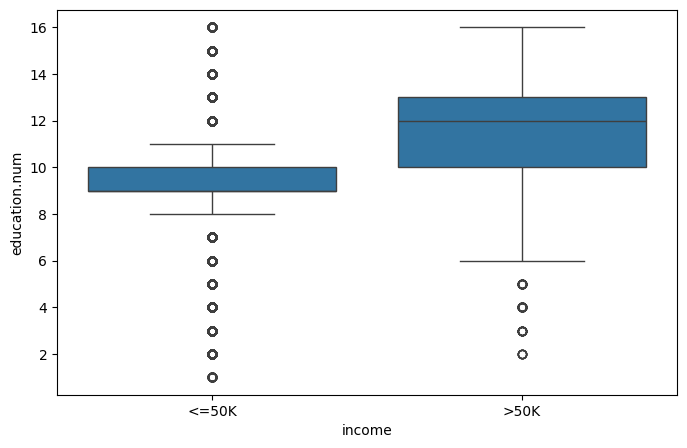

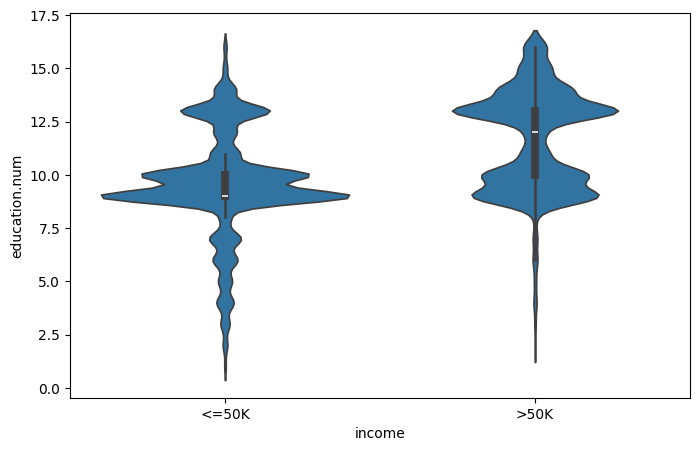

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,24720.0,9.595065,2.436147,1.0,9.0,9.0,10.0,16.0
>50K,7841.0,11.611657,2.385129,2.0,10.0,12.0,13.0,16.0


In [ ]:
# education num -
plt.figure(figsize=(8,5))

sns.boxplot(
    x='income',
    y='education.num',
    data=census
)

plt.show()

plt.figure(figsize=(8,5))

sns.violinplot(
    x='income',
    y='education.num',
    data=census
)

plt.show()

census.groupby('income')['education.num'].describe()

# okay so in this we can clearly see some diffrence btw the two catergories i belive this education num is the year the ppl have studied so byb that mean the more u study the more the chances is to earn more  by getting the opportunity, yes there is a diffrence but not that drastic , but it will defienirlty can help us difrentitaten

# i am jst curious about the voilin graph over here and in this i can see a similar pattern bte the both of shapes, the shapes here resemble the hour glass shaoe and noth have that narrow dip at 12.5 then grown out again at 13 or 13.5 and on 9 to 10 aswell they have speard .
# and yes there is the clear diffrene acoording to the cross tab as well so i think we should definitely keep thois 

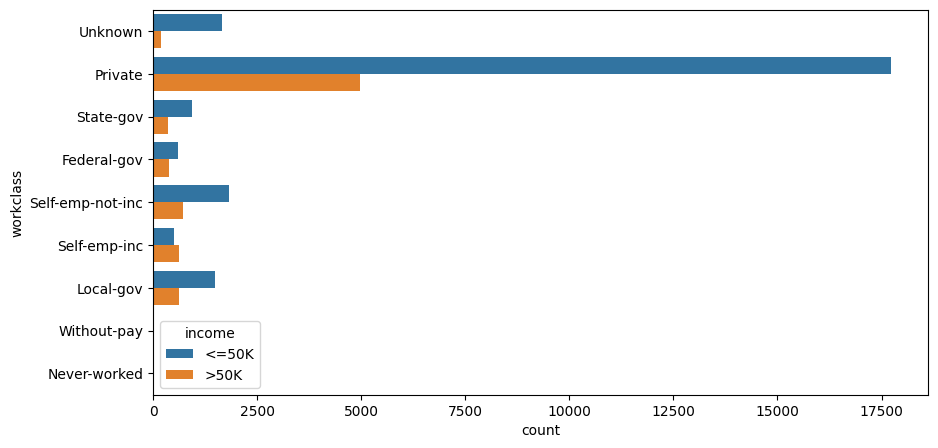

income,<=50K,>50K
workclass,,
Federal-gov,61.354167,38.645833
Local-gov,70.520784,29.479216
Never-worked,100.000000,0.000000
Private,78.132711,21.867289
Self-emp-inc,44.265233,55.734767
Self-emp-not-inc,71.507281,28.492719
State-gov,72.804314,27.195686
Unknown,89.596950,10.403050
Without-pay,100.000000,0.000000


In [99]:
# work class -->

census['workclass'].value_counts()

pd.crosstab(
    census['workclass'],
    census['income'],
    normalize='index'
) * 100

plt.figure(figsize=(10,5))

sns.countplot(
    y='workclass',
    hue='income',
    data=census
)

plt.show()
pd.crosstab(
    census['workclass'],
    census['income'],
    normalize='index'
) * 100

# we can see the clear diffrennce inthe workclass then we should keep it

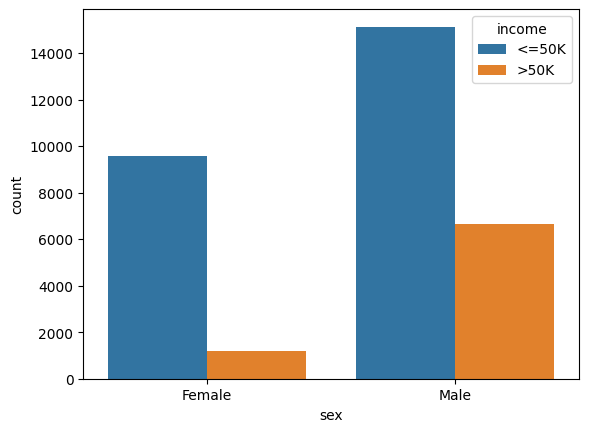

income,<=50K,>50K
sex,,
Female,89.053941,10.946059
Male,69.426342,30.573658


In [ ]:
# sex ->

sns.countplot(
    x='sex',
    hue='income',
    data=census
)

plt.show()

pd.crosstab(
    census['sex'],
    census['income'],
    normalize='index'
) * 100

# in sex male are earning more then female 

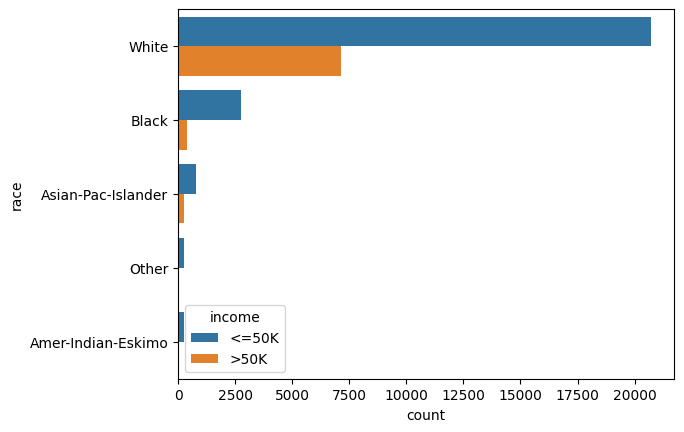

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,88.424437,11.575563
Asian-Pac-Islander,73.435996,26.564004
Black,87.612036,12.387964
Other,90.774908,9.225092
White,74.414006,25.585994


In [ ]:
# race - 

sns.countplot(
    y='race',
    hue='income',
    data=census
)

plt.show()
pd.crosstab(
    census['race'],
    census['income'],
    normalize='index'
) * 100

# in race white are earning more 

In [ ]:
# native country -

census['native.country'].value_counts().head(10)

(pd.crosstab(
    census['native.country'],
    census['income'],
    normalize='index',
    
) * 100)

# indian france and canadian are erning more 

income,<=50K,>50K
native.country,,
Cambodia,63.157895,36.842105
Canada,67.768595,32.231405
China,73.333333,26.666667
Columbia,96.610169,3.389831
Cuba,73.684211,26.315789
Dominican-Republic,97.142857,2.857143
Ecuador,85.714286,14.285714
El-Salvador,91.509434,8.490566
England,66.666667,33.333333


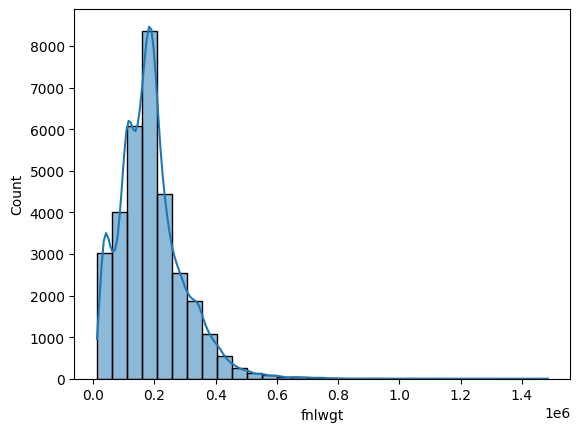

In [ ]:
census['fnlwgt'].describe()

sns.histplot(
    census['fnlwgt'],
    bins=30,
    kde=True
)

plt.show()

# i did not understand this fnlwght what do i need to do with it and how and am i supposed to juddge from it ?

In [107]:
# # FEATURE ENGINERRING --> BASIC CRASH COURSE ON FEATURE ENGINEERING

# There are 5 common things we check
# 1. Drop useless columns

# Ask:

# Does this feature actually help predict the target?

# Example:

# fnlwgt

# We already decided:

# ❌ Drop

# 2. Create new features

# Example:

# Instead of

# Age
# Hours

# Create

# Income_per_Hour

# or

# Experience_Group

# if appropriate.

# We won't invent unnecessary features just because we can.

# 3. Merge categories

# Example

# Suppose we had

# Country

# France

# Germany

# Italy

# Spain

# Portugal

# Each has only 10 people.

# We might combine them into

# Europe

# to reduce sparsity.

# 4. Transform skewed features

# Remember

# Capital Gain

# Looked like

# 0 0 0 0 0 0 5000 9000 99999

# That's extremely skewed.

# Sometimes we apply

# np.log1p()

# to compress the huge values.

# 5. Remove redundancy

# Remember

# Education

# Education Number

# These two represent almost the same information.

# We need to decide whether keeping both is beneficial.

In [ ]:
# ill try to do the feature enginnering with my personal experience and understanding

census.head(10)

# first we need to merge the education and the education num , remove the fnlwgt feature because its useless currently this what i know what we can do there is many more ahead 




,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,Unknown,>50K


In [ ]:
# removing the fnlwgt 

census.drop(columns='fnlwgt',  inplace=True)

In [ ]:
census[['education', 'education.num']]

print(census['education.num'].unique())
print(census['education'].unique())
print(census['education'].value_counts(ascending=False))


# so what i have got to know is that the education is a type of hirarchial diffrenctiable data so education nums give that ranking to it , so i think its already encoded we dont 
# need to do it again , so we can either drop the education or do some thing else with it 

# we are finally planning to drop the educaition cause it makes no sence to keep it .

[ 9 10  4  6 16 15 13 14  7 12 11  2  3  8  5  1]
<ArrowStringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64


In [121]:
census.drop(columns='education', inplace=True)

In [ ]:
# ENCODING -->

# | Feature         | Type    | Best Encoding        |
# | --------------- | ------- | -------------------- |
# | workclass       | Nominal | One-Hot              |
# | marital.status  | Nominal | One-Hot              |
# | occupation      | Nominal | One-Hot              |
# | relationship    | Nominal | One-Hot              |
# | race            | Nominal | One-Hot              |
# | sex             | Binary  | Label Encoding (0/1) |
# | native.country  | Nominal | One-Hot              |
# | income (Target) | Binary  | Label Encoding (0/1) |

# small insight for the encoding -->
    
# So the rule becomes
# If the method doesn't calculate anything

# Example:

# pd.get_dummies()

# ✅ Encode first.

# Then split.

# If the method calculates something

# Example:

# StandardScaler()

# SimpleImputer()

# MinMaxScaler()

# ✅ Split first.

# Then calculate using only the training data.




from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

census['income'] = le.fit_transform(census['income'])

In [123]:
census['income'].value_counts()

income
0    24720
1     7841
Name: count, dtype: int64

In [124]:
census = pd.get_dummies(
    census,
    columns=[
        'workclass',
        'marital.status',
        'occupation',
        'relationship',
        'race',
        'native.country'
    ],
    drop_first=True
)

In [125]:
census['sex'] = le.fit_transform(census['sex'])

In [126]:
census.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 85 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        32561 non-null  int64
 1   education.num                              32561 non-null  int64
 2   sex                                        32561 non-null  int64
 3   capital.gain                               32561 non-null  int64
 4   capital.loss                               32561 non-null  int64
 5   hours.per.week                             32561 non-null  int64
 6   income                                     32561 non-null  int64
 7   workclass_Local-gov                        32561 non-null  bool 
 8   workclass_Never-worked                     32561 non-null  bool 
 9   workclass_Private                          32561 non-null  bool 
 10  workclass_Self-emp-inc                     32561 non-null

In [128]:
census.shape

(32561, 85)

In [129]:
# TRAIN TEST SPLIT  -->

X = census.drop('income', axis=1)

y = census['income']

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# # okay so we do not need to do scalling in the naive bayes ill give you and metion the simplest expamles to it that
# # there is no comparison btw the age and the captal gain and the loss so e do need it here inthi scase 

# What do we do in THIS project?

# We do not scale the data.

# Why?

# Gaussian Naive Bayes does not require it.
# We want to learn the algorithm in its standard form first.
# If we later want to experiment, we can compare:
# Model A: Without scaling
# Model B: With scaling

# That's a valid experiment, but not a requirement.

(26048, 84)
(6513, 84)
(26048,)
(6513,)


In [135]:
# running the naive bayes code --> creating  the model

from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)



,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[19775., 6273.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.76,0.24]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.05496
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](84,)","['age','education.num','sex',...,'native.country_Unknown', 'native.country_Vietnam','native.country_Yugoslavia']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,84
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 84)","[[36.74, 9.6 , 0.61,..., 0.02, 0. , 0. ], [44.16,11.6 , 0.85,..., 0.02, 0. , 0. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 84)","[[196.84, 6.03, 0.29,..., 0.07, 0.06, 0.06], [109.23, 5.74, 0.18,..., 0.07, 0.06, 0.06]]"


In [136]:
y_pred = model.predict(X_test)

In [137]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.8129894058037771

Confusion Matrix
[[4073  872]
 [ 346 1222]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      4945
           1       0.58      0.78      0.67      1568

    accuracy                           0.81      6513
   macro avg       0.75      0.80      0.77      6513
weighted avg       0.84      0.81      0.82      6513

ROC-AUC: 0.8014984987928437


In [ ]:
#                  Predicted

#                <=50K     >50K

# Actual <=50K    4073       872

# Actual >50K      346      1222